In [1]:
import pandas as pd
import numpy as np

PROCESSED = '../notebooks/data/processed'

X_train = pd.read_parquet(f'{PROCESSED}/X_train.parquet')
Y_train = pd.read_parquet(f'{PROCESSED}/Y_train.parquet').iloc[:, 0]
X_test  = pd.read_parquet(f'{PROCESSED}/X_test.parquet')
Y_test  = pd.read_parquet(f'{PROCESSED}/Y_test.parquet').iloc[:, 0]


print(f'X_train: {X_train.shape}')
print(f"X_test: {X_test.shape}")
print(f'Y_train fraud rate: {Y_train.mean():.3%}')
print(f'Y_test fraud rate: {Y_test.mean():.3%}')



X_train: (501416, 445)
X_test: (118108, 445)
Y_train fraud rate: 9.091%
Y_test fraud rate: 3.441%


In [2]:
import sys
sys.path.append('../')

from src.models.train import (train_xgboost_baseline, train_lightgbm_baseline, save_model)

from src.models.evaluate import evaluate_model, log_results, compare_runs




In [3]:
xgb_model = train_xgboost_baseline(X_train, Y_train)
lgbm_model = train_lightgbm_baseline(X_train,Y_train)





Training xgboost model:
[0]	validation_0-auc:0.87440
[1]	validation_0-auc:0.88789
[2]	validation_0-auc:0.90413
[3]	validation_0-auc:0.90594
[4]	validation_0-auc:0.90563
[5]	validation_0-auc:0.91193
[6]	validation_0-auc:0.91265
[7]	validation_0-auc:0.91270
[8]	validation_0-auc:0.91391
[9]	validation_0-auc:0.91434
[10]	validation_0-auc:0.91733
[11]	validation_0-auc:0.92225
[12]	validation_0-auc:0.92373
[13]	validation_0-auc:0.92427
[14]	validation_0-auc:0.92603
[15]	validation_0-auc:0.92747
[16]	validation_0-auc:0.92842
[17]	validation_0-auc:0.93005
[18]	validation_0-auc:0.93120
[19]	validation_0-auc:0.93230
[20]	validation_0-auc:0.93258
[21]	validation_0-auc:0.93416
[22]	validation_0-auc:0.93475
[23]	validation_0-auc:0.93557
[24]	validation_0-auc:0.93644
[25]	validation_0-auc:0.93694
[26]	validation_0-auc:0.93784
[27]	validation_0-auc:0.93841
[28]	validation_0-auc:0.93890
[29]	validation_0-auc:0.93932
[30]	validation_0-auc:0.93969
[31]	validation_0-auc:0.94012
[32]	validation_0-auc:0.94

In [4]:
xgb_results = evaluate_model(xgb_model, X_test, Y_test, model_name = "xgboost_baseline")

lgbm_results = evaluate_model(lgbm_model, X_test,Y_test, model_name = 'lgbm_baseline')

log_results(xgb_results)
log_results(lgbm_results)

compare_runs()

save_model(xgb_model, "xgboost_baseline")
save_model(lgbm_model,"lightgbm_baseline")




  xgboost_baseline
  AUC-ROC:            0.9012
  AUC-PR:             0.5246
  Precision:          0.8007
  Recall:             0.3253
  F1:                 0.4626
  False positive rate:0.0029
  Confusion matrix:
    TP=1,322  FP=329
    FN=2,742  TN=113,715

[LightGBM] [Warning] Unknown parameter: verbosre

  lgbm_baseline
  AUC-ROC:            0.8992
  AUC-PR:             0.5147
  Precision:          0.7871
  Recall:             0.3184
  F1:                 0.4534
  False positive rate:0.0031
  Confusion matrix:
    TP=1,294  FP=350
    FN=2,770  TN=113,694

Results logged to data/model_results\model_log.json
Results logged to data/model_results\model_log.json
      model_name  auc_roc  auc_pr  precision  recall     f1  false_positive_rate                  timestamp
xgboost_baseline   0.9012  0.5246     0.8007  0.3253 0.4626               0.0029 2026-08-12T13:49:37.008924
   lgbm_baseline   0.8992  0.5147     0.7871  0.3184 0.4534               0.0031 2026-08-12T13:49:38.689447
xgbo

'data/models/lightgbm_baseline.pkl'

In [5]:
import sys
sys.path.append('../')

from src.models.train import (tune_xgboost, save_model)

from src.models.evaluate import evaluate_model, log_results, compare_runs



In [6]:
tuned_xgb, study = tune_xgboost(X_train, Y_train, n_trials=50)

tuned_results = evaluate_model(
    tuned_xgb, X_test, Y_test,
    model_name="xgboost_tuned",

)

log_results(tuned_results)

save_model(tuned_xgb, "xgboost_tuned")

compare_runs()

  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC-PR (CV): 0.9640
Best params:
 n_estimators: 705
 learning_rate: 0.12963216466172517
 max_depth: 8
 subsample: 0.7015663799319409
 colsample_bytree: 0.9832675663386035
 min_child_weight: 1
 gamma: 0.3162663223081429
 reg_alpha: 5.167682983405994e-08
 reg_lambda: 5.7057896030047325e-06

Training final model with best params...

  xgboost_tuned
  AUC-ROC:            0.9070
  AUC-PR:             0.5758
  Precision:          0.8335
  Recall:             0.3942
  F1:                 0.5352
  False positive rate:0.0028
  Confusion matrix:
    TP=1,602  FP=320
    FN=2,462  TN=113,724

Results logged to data/model_results\model_log.json
Model saved to data/models/xgboost_tuned.pkl
      model_name  auc_roc  auc_pr  precision  recall     f1  false_positive_rate                  timestamp
xgboost_baseline   0.9012  0.5246     0.8007  0.3253 0.4626               0.0029 2026-08-12T13:49:37.008924
   lgbm_baseline   0.8992  0.5147     0.7871  0.3184 0.4534               0.0031 2026-08-12T

,model_name,auc_roc,auc_pr,precision,recall,f1,false_positive_rate,timestamp
0,xgboost_baseline,0.9012,0.5246,0.8007,0.3253,0.4626,0.0029,2026-08-12T13:49:37.008924
1,lgbm_baseline,0.8992,0.5147,0.7871,0.3184,0.4534,0.0031,2026-08-12T13:49:38.689447
2,xgboost_baseline,0.9012,0.5246,0.8007,0.3253,0.4626,0.0029,2026-08-12T14:58:30.177928
3,lgbm_baseline,0.8992,0.5147,0.7871,0.3184,0.4534,0.0031,2026-08-12T14:58:32.099839
4,xgboost_baseline,0.9012,0.5246,0.8007,0.3253,0.4626,0.0029,2026-08-12T15:04:19.624105
5,lgbm_baseline,0.8992,0.5147,0.7871,0.3184,0.4534,0.0031,2026-08-12T15:04:21.692837
6,xgboost_baseline,0.9012,0.5246,0.8007,0.3253,0.4626,0.0029,2026-08-12T15:11:07.636056
7,lgbm_baseline,0.8992,0.5147,0.7871,0.3184,0.4534,0.0031,2026-08-12T15:11:09.912903
8,xgboost_tuned,0.9070,0.5758,0.8335,0.3942,0.5352,0.0028,2026-08-13T01:30:17.916431


Best threshold: 0.2161
At this threshold:
  Precision: 0.6990
  Recall:    0.4845
  F1:        0.5723


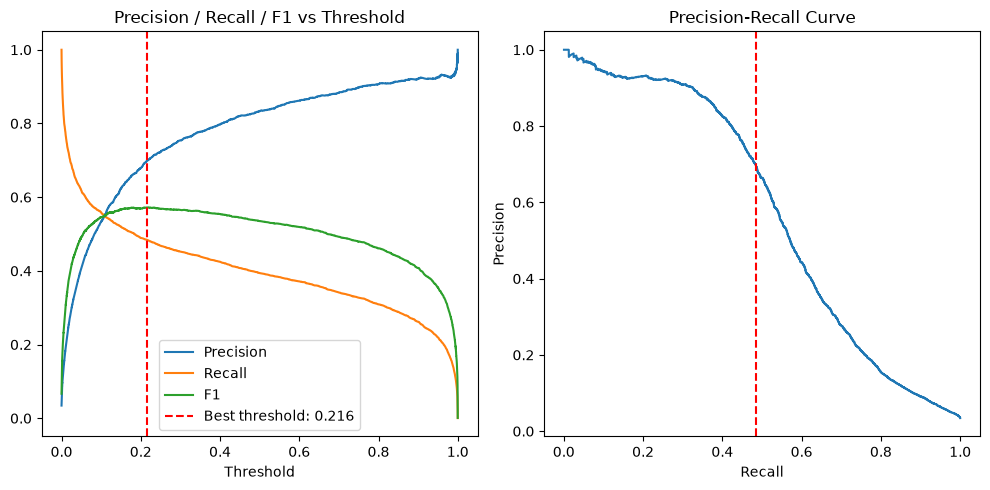

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

Y_prob = tuned_xgb.predict_proba(X_test)[:,1]

precisions, recalls, thresholds = precision_recall_curve(Y_test,Y_prob)

f1_score  = 2* (precisions*recalls)/ (precisions + recalls + 1e-8)
best_idx = f1_score.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.4f}")
print(f"At this threshold:")
print(f"  Precision: {precisions[best_idx]:.4f}")
print(f"  Recall:    {recalls[best_idx]:.4f}")
print(f"  F1:        {f1_score[best_idx]:.4f}")


plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_score[:-1], label='F1')
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Best threshold: {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(recalls[:-1], precisions[:-1])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.axvline(recalls[best_idx], color='red', linestyle='--')

plt.tight_layout()
plt.show()




In [10]:
import os

log_path = 'data/model_results/model_log.json'
if os.path.exists(log_path):
    os.remove(log_path)
    print("Corrupted log deleted")

Corrupted log deleted


In [11]:
from src.models.evaluate import evaluate_model, log_results, compare_runs

Y_prob = tuned_xgb.predict_proba(X_test)[:, 1]

tuned_results = evaluate_model(
    tuned_xgb, X_test, Y_test,
    threshold=0.5,
    model_name="xgboost_tuned"
)

tuned_results_optimal = evaluate_model(
    tuned_xgb, X_test, Y_test,
    threshold=0.2161,
    model_name="xgboost_tuned_optimal_threshold"
)

log_results(tuned_results)
log_results(tuned_results_optimal)
compare_runs()


  xgboost_tuned
  AUC-ROC:            0.9070
  AUC-PR:             0.5758
  Precision:          0.8335
  Recall:             0.3942
  F1:                 0.5352
  False positive rate:0.0028
  Confusion matrix:
    TP=1,602  FP=320
    FN=2,462  TN=113,724


  xgboost_tuned_optimal_threshold
  AUC-ROC:            0.9070
  AUC-PR:             0.5758
  Precision:          0.6988
  Recall:             0.4840
  F1:                 0.5719
  False positive rate:0.0074
  Confusion matrix:
    TP=1,967  FP=848
    FN=2,097  TN=113,196

Results logged to data/model_results\model_log.json
Results logged to data/model_results\model_log.json
                     model_name  auc_roc  auc_pr  precision  recall     f1  false_positive_rate                  timestamp
                  xgboost_tuned    0.907  0.5758     0.8335  0.3942 0.5352               0.0028 2026-08-13T12:56:20.742904
xgboost_tuned_optimal_threshold    0.907  0.5758     0.6988  0.4840 0.5719               0.0074 2026-08-13T12:56:21.

,model_name,auc_roc,auc_pr,precision,recall,f1,false_positive_rate,timestamp
0,xgboost_tuned,0.907,0.5758,0.8335,0.3942,0.5352,0.0028,2026-08-13T12:56:20.742904
1,xgboost_tuned_optimal_threshold,0.907,0.5758,0.6988,0.4840,0.5719,0.0074,2026-08-13T12:56:21.489262


In [15]:
import os
import joblib

# Create directory if it doesn't exist
os.makedirs('data/models/', exist_ok=True)

# Save to notebooks/data/models/ (same pattern as processed data)
model_bundle = {
    "model": tuned_xgb,
    "threshold": best_threshold,
    "metrics": tuned_results_optimal
}

joblib.dump(model_bundle, 'data/models/xgboost_production.pkl')
print(f"Model bundle saved with threshold: {best_threshold:.4f}")

Model bundle saved with threshold: 0.2161
